# dirFR sample plots — primacy vs recency initiation

This notebook reuses `analyses.spc_sess` and `analyses.pfr_sess` from `analyses.py`
— the per-session computation functions, but bypasses the groupby wrappers that
were written for the old MTurk design's stimulus conditions.

## 0. Load and Clean

In [521]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.analyses as analyses
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality
from data.recall_inspection import inspect_list_recall

In [522]:
# Loads the most recent pulled CSV file from data/data_storage 
data_dir = Path('data/data_storage') # create path to folder 
try:
    data_path = max(data_dir.glob('dirfr_trials*.csv'), key=lambda p: p.stat().st_mtime) # get most recent trial csv
except ValueError:
    raise FileNotFoundError(f'No dirfr_trials*.csv files found in {data_dir}')
raw = pd.read_csv(data_path)
print(f'Loaded {data_path}')

Loaded data/data_storage/dirfr_trials_20260513_103005.csv


In [523]:
# Manual Exclusion
exclude_pid = ['5ece82a1ba09f524e15d973b']
print(f'Before exclusion: {len(raw)} rows')
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
print(f'After exclusion: {len(raw)} rows')
print(f'Excluded data (Prolific IDs: {exclude_pid})')

Before exclusion: 72507 rows
After exclusion: 70100 rows
Excluded data (Prolific IDs: ['5ece82a1ba09f524e15d973b'])


In [524]:
# Keep only word-presentation and recall rows - analyses.spc_sess / pfr_sess use these
df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()

# Ensure numeric dtypes (raw CSV mixes schemas across rows)
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check
type(df['serial_position'].iloc[0]), type(df['list'].iloc[0]), type(df['session'].iloc[0]), type(df['l_length'].iloc[0]), type(df['rt'].iloc[0])

(numpy.float64, numpy.float64, numpy.int64, numpy.float64, numpy.float64)

In [525]:
# Build lookup: presented WORD -> serial position
word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(
    ['prolific_pid', 'session', 'list', 'word_key']
)['serial_position'].to_dict()

# recompute serial positions for REC_WORD
def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88) # return serial position if found else 88 

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df) # add spellcheck following original study, Levenshtein dist <= 1 

Damerau-Levenshtein spellcheck corrected 861 recall(s).


In [526]:
df_before_quality = df.copy()
df_after_quality = filter_sessions_by_quality(df_before_quality, raw)

before_sessions = df_before_quality[['prolific_pid', 'session']].drop_duplicates()
after_sessions = df_after_quality[['prolific_pid', 'session']].drop_duplicates()

excluded_sessions = (
    before_sessions
    .merge(after_sessions, on=['prolific_pid', 'session'], how='left', indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
    .sort_values(['prolific_pid', 'session'])
)

excluded = len(excluded_sessions)

print(f"Excluded sessions by quality criteria: {excluded}")
display(excluded_sessions)

df = df_after_quality


Participant 602fd11faa844cd2d0fd5818 in session 4 took notes.
Participant 69dc70961c94f47c2fdced04 in session 0 took notes.
Excluded sessions by quality criteria: 2


,prolific_pid,session
61,602fd11faa844cd2d0fd5818,4
179,69dc70961c94f47c2fdced04,0


## 1. Inspection

In [528]:
# Metadata Inspection
session_info = df[['prolific_pid', 'session', 'initiation_condition']].drop_duplicates(['prolific_pid', 'session'])
twoplus_sessions = session_info.groupby('prolific_pid')['session'].nunique().loc[lambda s: s > 2]
print(f'{len(df)} rows across {session_info["prolific_pid"].nunique()} participants, {len(session_info)} sessions')
print(f"Condition breakdown by session: {session_info['initiation_condition'].value_counts().to_dict()}")
print(f'Participants with 2+ included session: {len(twoplus_sessions)}')

print("Total Sessions Completed:", session_info['session'].nunique())
counts = session_info['session'].value_counts().sort_index()
counts.index = [f"Session {i}" for i in counts.index]
print(counts)

55970 rows across 109 participants, 196 sessions
Condition breakdown by session: {'primacy': 101, 'recency': 95}
Participants with 2+ included session: 17
Total Sessions Completed: 5
Session 0    109
Session 1     50
Session 2     17
Session 3     13
Session 4      7
Name: count, dtype: int64


In [593]:
# Per-Subject Inspection
pid = '69ff7a564db9204d3b23cd31' # (replace with actual Prolific ID of interest)

# 1) Number of sessions completed
n_sessions = session_info[session_info['prolific_pid'] == pid]['session'].nunique()

# 2) Condition per session
print(f"Condition per Session:")
for i in range(n_sessions):
    condition = session_info[(session_info['prolific_pid'] == pid) & (session_info['session'] == i)]['initiation_condition'].iloc[0]
    print(f"Session {i}: {condition}")

# 3) Mean words recalled per list per session
print(f"Mean Words Recalled per Session:")
for i in range(n_sessions):
    data = df_before_quality[(df_before_quality['prolific_pid'] == pid) & (df_before_quality['session'] == i)]
    mwr = analyses.mwr_sess(data)
    print(f"Session {i}: {mwr}")

Condition per Session:
Session 0: recency
Session 1: recency
Mean Words Recalled per Session:
Session 0: 6.5
Session 1: 9.25


In [638]:
# Per-List Inspection
pid = '698651b5bbcfef723824cb98' # (replace with actual Prolific ID of interest)
session = 3
list_num = 11

selected = df.query("prolific_pid == @pid and session == @session and list == @list_num")
condition = selected['initiation_condition'].dropna().iloc[0]
ll = int(selected['l_length'].dropna().iloc[0])
recalls = selected[selected['type'] == 'REC_WORD']['serial_position']
correct_unique = recalls[(recalls >= 1) & (recalls <= ll)].astype(int).nunique()

print(f'Participant {pid}, Session {session}, List {list_num}')
print(f'Initiation direction: {condition}')
print(f'Words recalled: {correct_unique}')
inspect_list_recall(df, pid, session, list_num)

Participant 698651b5bbcfef723824cb98, Session 3, List 11
Initiation direction: primacy
Words recalled: 5


,serial_position,word_shown,recalled_word,recalled_serial_position,intrusion_type
row,,,,,
1,1,woman,woman,1,correct
2,2,label,palace,16,correct
3,3,snail,cobra,19,correct
4,4,pastry,grape,20,correct
5,5,umpire,football,9,correct
6,6,bike,(empty),no response,no response
7,7,judge,NaN,NaN,NaN
8,8,raft,NaN,NaN,NaN
9,9,football,NaN,NaN,NaN


## 2. Demographics


In [10]:
included_pids = df['prolific_pid'].unique()
demog_raw = raw[raw['prolific_pid'].isin(included_pids)].copy()

In [11]:
age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)

age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_stats = age_df['age'].describe()
age_stats 

count    20.000000
mean     25.500000
std       3.486817
min      20.000000
25%      22.750000
50%      25.500000
75%      28.000000
max      33.000000
Name: age, dtype: float64

In [12]:
gender_map = {
    0: 'Male',
    1: 'Female',
    2: 'Other',
    3: 'Prefer not to answer',
}

gender_df = (
    demog_raw.query("type == 'gender'")[['prolific_pid', 'response']]
    .drop_duplicates('prolific_pid')
    .copy()
)

gender_overrides = {
    '65cb7d52b59b7dd58392e0ba': 'Female'
}

gender_df['gender'] = (
    pd.to_numeric(gender_df['response'], errors='coerce')
    .map(gender_map)
    .fillna('Unknown')
)

gender_df.head(5)

,prolific_pid,response,gender
2413,69eb1df8219c8467eb86f444,1,Female
2674,6993ef10052ab64910f5b6cc,1,Female
2928,69d0c2ae9394bed26d131574,1,Female
3214,663bb62ffe083ca847014fbb,0,Male
3515,5a8895f0f1408d0001769b7b,1,Female


In [13]:
demographics_df = age_df.merge(
    gender_df[['prolific_pid', 'gender']],
    on='prolific_pid',
    how='outer'
)

demographics_df.head(5)

,prolific_pid,age,gender
0,5a8895f0f1408d0001769b7b,28.0,Female
1,602fd11faa844cd2d0fd5818,33.0,Male
2,655f8b959477c803eb906622,22.0,Female
3,65cb7d52b59b7dd58392e0ba,28.0,Male
4,663bb62ffe083ca847014fbb,28.0,Male


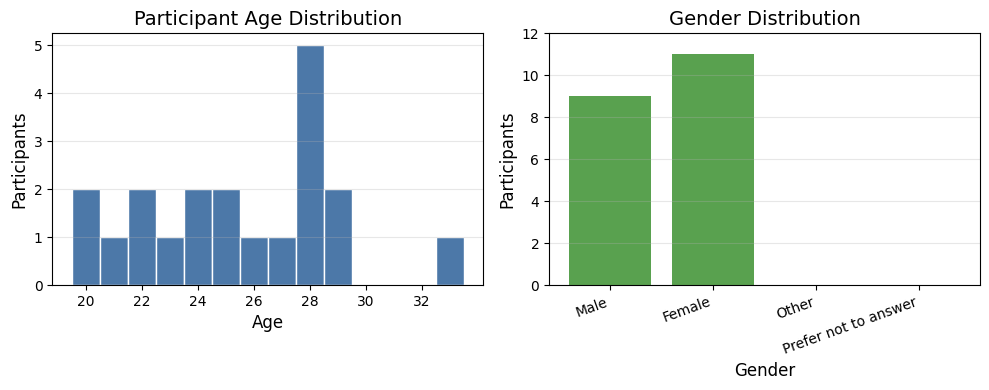

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(
    demographics_df['age'].min() - 0.5,
    demographics_df['age'].max() + 1.5,
    1,
)
ax[0].hist(demographics_df['age'].dropna(), bins=bins, color='#4c78a8', edgecolor='white')
ax[0].set_xlabel('Age', fontsize=12)
ax[0].set_ylabel('Participants', fontsize=12)
ax[0].set_title('Participant Age Distribution', fontsize=14)
ax[0].set_xticks(np.arange(demographics_df['age'].min(), demographics_df['age'].max() + 1, 2))
ax[0].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/age_histogram.png', dpi=150)

gender_counts = demographics_df['gender'].value_counts().reindex(gender_map.values(), fill_value=0)
ax[1].bar(gender_counts.index, gender_counts.values, color='#59a14f')
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Participants', fontsize=12)
ax[1].set_title('Gender Distribution', fontsize=14)
ax[1].set_ylim(0, max(gender_counts.max() + 1, 1))
ax[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/gender_distribution.png', dpi=150)
plt.show()

## Plotting Helpers

In [15]:
cond_order = [c for c in ['primacy', 'recency'] if c in df['initiation_condition'].dropna().unique()]
colors = {'primacy': '#1f77b4', 'recency': '#d62728'}

def participant_condition_average(data, value_cols, extra_group_cols=None):
    group_cols = ['prolific_pid', 'initiation_condition']
    if extra_group_cols:
        group_cols += extra_group_cols

    return data.groupby(group_cols, as_index=False)[value_cols].mean()


def condition_summary(data, value_cols, extra_group_cols=None):
    participant_df = participant_condition_average(data, value_cols, extra_group_cols)

    group_cols = ['initiation_condition'] + (extra_group_cols or [])

    mean = participant_df.groupby(group_cols)[value_cols].mean()
    sem = participant_df.groupby(group_cols)[value_cols].sem()
    n = participant_df.groupby(group_cols)['prolific_pid'].nunique().rename('n_participants')

    return participant_df, mean, sem, n


def plot_curve_by_condition(curve_df, value_cols, ylabel, title, figure_path):
    participant_df, mean, sem, n = condition_summary(curve_df, value_cols)
    positions = np.arange(1, len(value_cols) + 1)

    fig, ax = plt.subplots(figsize=(6,4))

    for cond in cond_order:
        if cond not in mean.index:
            continue

        vals = mean.loc[cond, value_cols].values
        errs = sem.loc[cond, value_cols].fillna(0).values
        n_participants = int(n.loc[cond])

        ax.errorbar(
            positions,
            vals,
            yerr=errs,
            label=f'{cond.capitalize()} (n={n_participants})',
            color=colors.get(cond, 'gray'),
            marker='o',
            capsize=3,
        )

    ax.set_xlabel('Serial Position', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.set_xticks(positions)
    ax.set_ylim(0, 1)
    ax.legend(title='Initiation')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(figure_path, dpi=150)
    plt.show()

    return participant_df

def plot_bar_by_condition(metric_df, value_col, ylabel, title, figure_path, chance=None):
    participant_df, mean, sem, n = condition_summary(metric_df, [value_col])

    plot_mean = mean[value_col].reindex(cond_order)
    plot_sem = sem[value_col].reindex(cond_order).fillna(0)
    plot_n = n.reindex(cond_order).fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(6, 4.5))

    ax.bar(
        np.arange(len(cond_order)),
        plot_mean,
        yerr=plot_sem,
        color=[colors[c] for c in cond_order],
        capsize=5,
        alpha=0.8,
    )

    if chance is not None:
        ax.axhline(
            chance,
            color='black',
            linestyle='--',
            alpha=0.5,
            label=f'Chance ({chance})',
        )
        ax.legend()

    ax.set_xticks(np.arange(len(cond_order)))
    ax.set_xticklabels(
        [f'{c.capitalize()}\n(n={plot_n.loc[c]} p)' for c in cond_order],
        fontsize=12,
    )
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(figure_path, dpi=150)
    plt.show()

    return participant_df


## 3. Mean words recalled

For each session, `mwr_sess` returns the average number of correct recalls
per list.

In [16]:
mwr_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    cond = data['initiation_condition'].dropna().iloc[0]
    mwr = analyses.mwr_sess(data)
    mwr_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond, 'mwr': mwr
    })
mwr_df = pd.DataFrame(mwr_rows)
mwr_df.head(5)

,prolific_pid,session,initiation_condition,mwr
0,5a8895f0f1408d0001769b7b,0,primacy,4.166667
1,602fd11faa844cd2d0fd5818,0,recency,4.333333
2,602fd11faa844cd2d0fd5818,1,recency,9.916667
3,602fd11faa844cd2d0fd5818,2,primacy,6.916667
4,602fd11faa844cd2d0fd5818,3,primacy,8.416667


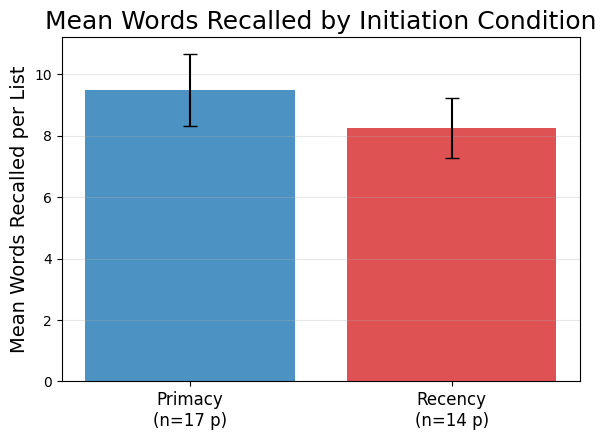

In [17]:
mwr_participant_df = plot_bar_by_condition(
    mwr_df,
    value_col='mwr',
    ylabel='Mean Words Recalled per List',
    title='Mean Words Recalled by Initiation Condition',
    figure_path='figures/mwr_by_condition.png',
)


## 4. Serial Position Curve (SPC)

In [18]:
spc_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    ll = int(data['l_length'].dropna().iloc[0])
    cond = data['initiation_condition'].dropna().iloc[0]
    spc = analyses.spc_sess(data, ll)
    spc_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond, 'l_length': ll,
        **{f'sp_{i+1}': spc[i] for i in range(ll)}
    })
spc_df = pd.DataFrame(spc_rows)
spc_df.head(5)

,prolific_pid,session,initiation_condition,l_length,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5a8895f0f1408d0001769b7b,0,primacy,20,1.000000,0.500000,0.333333,0.000000,0.000000,0.166667,...,0.000000,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.333333,0.500000,0.833333
1,602fd11faa844cd2d0fd5818,0,recency,20,0.166667,0.166667,0.166667,0.166667,0.333333,0.166667,...,0.000000,0.333333,0.166667,0.166667,0.333333,0.166667,0.166667,0.500000,0.333333,0.166667
2,602fd11faa844cd2d0fd5818,1,recency,20,0.583333,0.583333,0.416667,0.583333,0.416667,0.416667,...,0.333333,0.500000,0.666667,0.416667,0.250000,0.750000,0.416667,0.583333,0.333333,0.750000
3,602fd11faa844cd2d0fd5818,2,primacy,20,0.500000,0.250000,0.250000,0.250000,0.333333,0.416667,...,0.166667,0.333333,0.083333,0.250000,0.250000,0.333333,0.416667,0.500000,0.416667,0.666667
4,602fd11faa844cd2d0fd5818,3,primacy,20,0.916667,0.333333,0.416667,0.416667,0.333333,0.583333,...,0.333333,0.250000,0.500000,0.333333,0.583333,0.500000,0.250000,0.333333,0.583333,0.416667


In [19]:
df_temp = df[['prolific_pid', 'initiation_condition', 'session']].drop_duplicates()

counts = (
    df_temp.groupby('prolific_pid')['initiation_condition']
    .unique().explode().value_counts()
)

print(counts)

initiation_condition
primacy    17
recency    14
Name: count, dtype: int64


Participants are the unit of analysis. If a participant completed more than one
session in the same condition, those sessions are averaged first; condition
means and SEMs are then computed across participants.


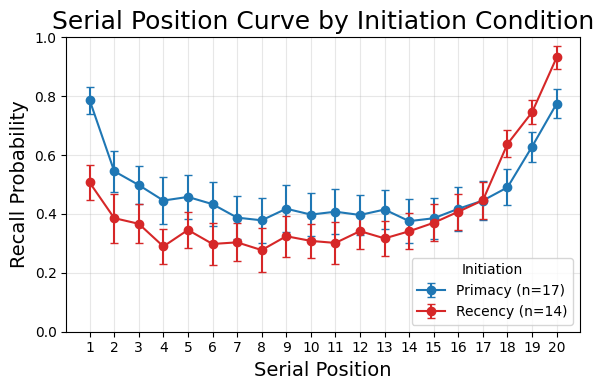

In [20]:
sp_cols = [c for c in spc_df.columns if c.startswith('sp_')]
ll = len(sp_cols)
positions = np.arange(1, ll + 1)

spc_participant_df = plot_curve_by_condition(
    spc_df,
    sp_cols,
    ylabel='Recall Probability',
    title='Serial Position Curve by Initiation Condition',
    figure_path='figures/spc_by_condition.png',
)

## 4. Probability of First Recall

Uses `pfr_sess` with `toggle=True` (only lists that started with a correct recall, not an intrusion).

In [21]:
pfr_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    ll = int(data['l_length'].dropna().iloc[0])
    cond = data['initiation_condition'].dropna().iloc[0]
    pfr = analyses.pfr_sess(data, ll, toggle=True)
    pfr_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond, 'l_length': ll,
        **{f'sp_{i+1}': pfr[i] for i in range(ll)}
    })
pfr_df = pd.DataFrame(pfr_rows)

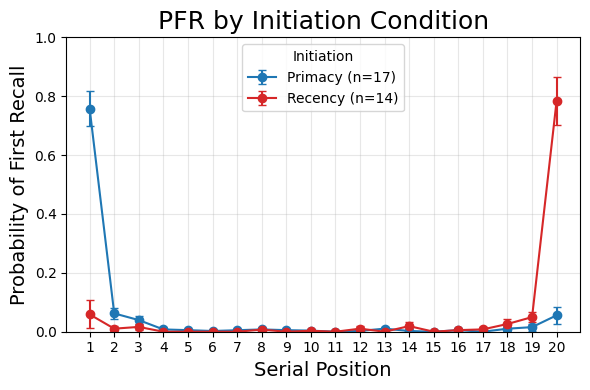

In [22]:
pfr_participant_df = plot_curve_by_condition(
    pfr_df,
    sp_cols,
    ylabel='Probability of First Recall',
    title='PFR by Initiation Condition',
    figure_path='figures/pfr_by_condition.png',
)

## Session-by-session SPC/PFR

These plots keep session number visible while still averaging repeated
participant-session rows correctly within each condition.


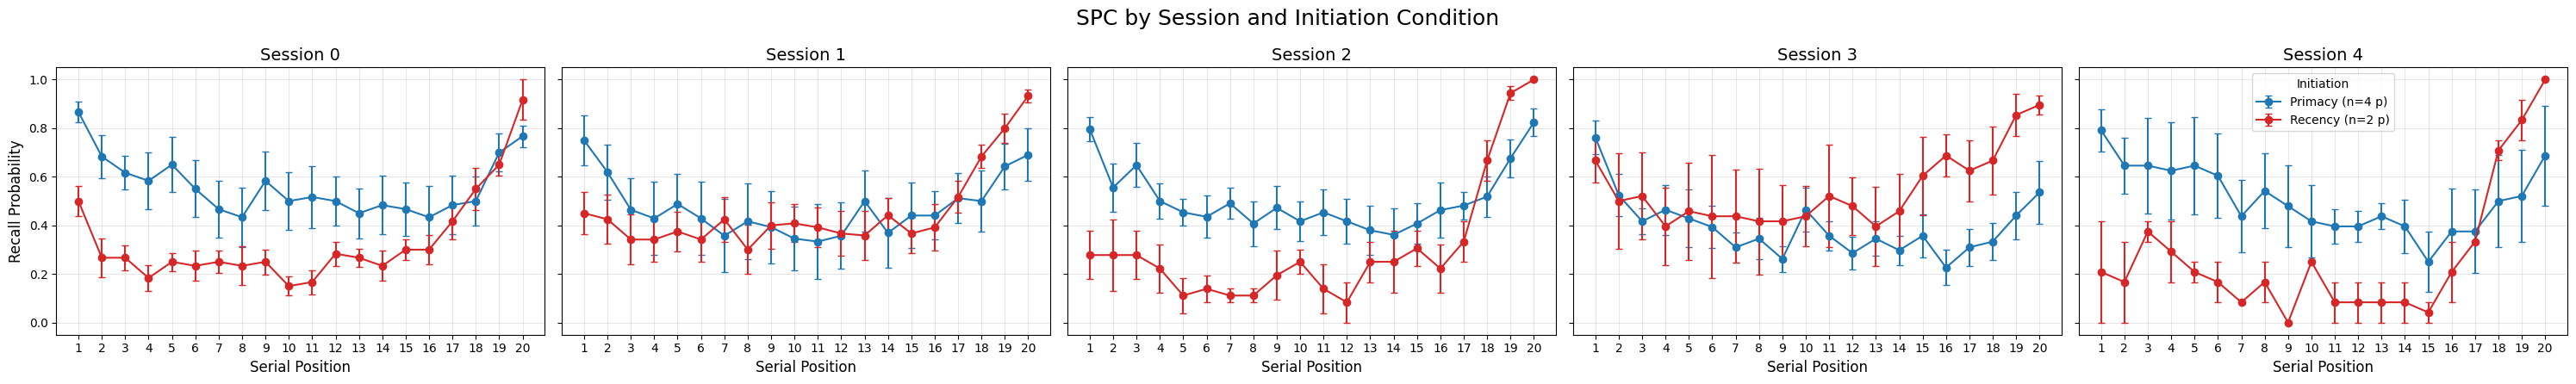

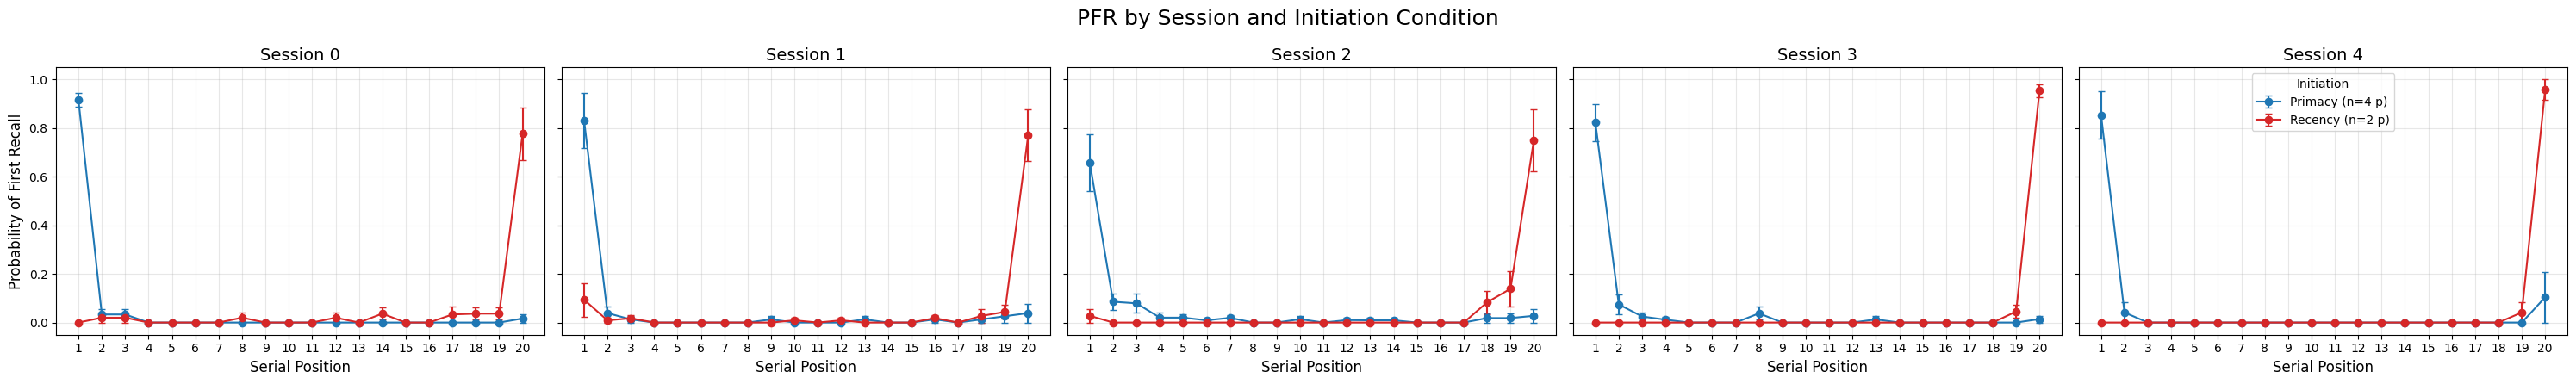

In [23]:
def plot_curve_by_session(curve_df, value_cols, ylabel, title, figure_path):
    sessions = sorted(curve_df['session'].dropna().unique())
    fig, axes = plt.subplots(1, len(sessions), figsize=(6 * len(sessions), 4.5), sharey=True)
    if len(sessions) == 1:
        axes = [axes]

    for ax, sess in zip(axes, sessions):
        sess_df = curve_df[curve_df['session'] == sess]
        _, mean, sem, n = condition_summary(sess_df, value_cols)
        positions = np.arange(1, len(value_cols) + 1)
        for cond in cond_order:
            if cond not in mean.index:
                continue
            vals = mean.loc[cond, value_cols].values
            errs = sem.loc[cond, value_cols].fillna(0).values
            ax.errorbar(
                positions, vals, yerr=errs,
                label=f'{cond.capitalize()} (n={int(n.loc[cond])} p)',
                color=colors.get(cond, 'gray'), marker='o', capsize=3
            )
        ax.set_title(f'Session {int(sess)}', fontsize=14)
        ax.set_xlabel('Serial Position', fontsize=12)
        ax.set_xticks(positions)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(ylabel, fontsize=12)
    axes[-1].legend(title='Initiation')
    fig.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.savefig(figure_path, dpi=150)
    plt.show()

plot_curve_by_session(
    spc_df, sp_cols,
    ylabel='Recall Probability',
    title='SPC by Session and Initiation Condition',
    figure_path='figures/spc_by_session.png',
)
plot_curve_by_session(
    pfr_df, sp_cols,
    ylabel='Probability of First Recall',
    title='PFR by Session and Initiation Condition',
    figure_path='figures/pfr_by_session.png',
)


### Initial response time

`rt_init_sess` estimates initiation latency per session. The plot averages
sessions within participant-condition before computing condition means.


In [24]:
rt_init_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    ll = int(data['l_length'].dropna().iloc[0])
    cond = data['initiation_condition'].dropna().iloc[0]
    rt_init_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond,
        'rt_init': analyses.rt_init_sess(data, ll, toggle=True)
    })
rt_init_df = pd.DataFrame(rt_init_rows)
display(rt_init_df)


,prolific_pid,session,initiation_condition,rt_init
0,5a8895f0f1408d0001769b7b,0,primacy,502.066667
1,602fd11faa844cd2d0fd5818,0,recency,3500.620000
2,602fd11faa844cd2d0fd5818,1,recency,3602.000000
3,602fd11faa844cd2d0fd5818,2,primacy,2991.700000
4,602fd11faa844cd2d0fd5818,3,primacy,2231.981818
...,...,...,...,...
61,69eb5bea0282ba37e5a2bae6,0,primacy,537.800000
62,69eb5bea0282ba37e5a2bae6,1,primacy,883.209091
63,69eb5bea0282ba37e5a2bae6,2,primacy,1295.025000
64,69eb5bea0282ba37e5a2bae6,3,primacy,1981.125000


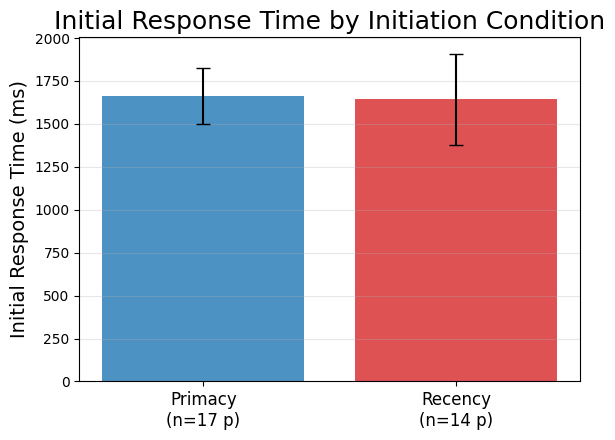

In [25]:
rt_init_participant_df = plot_bar_by_condition(
    rt_init_df,
    value_col='rt_init',
    ylabel='Initial Response Time (ms)',
    title='Initial Response Time by Initiation Condition',
    figure_path='figures/rt_init_by_condition.png',
)


### Intrusion rates

ELI = extra-list intrusions (never-presented words, or words from *future* lists).
PLI = prior-list intrusions (words from *earlier* lists, with a 4-list buffer).

`intrusion_rates_sess` returns a tuple `(eli_rate, pli_rate)`. The `toggle=True`
argument restricts to lists where recall was initiated with a correct word
(not an intrusion).

Note: `intrusion_rates_sess` now filters null-recall rows before pairing serial positions with recalled words and uses the corrected PLI-rate denominator.


In [26]:
intrusion_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    cond = data['initiation_condition'].dropna().iloc[0]
    eli, pli = analyses.intrusion_rates_sess(data, toggle=True)
    intrusion_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond,
        'eli_rate': eli, 'pli_rate': pli
    })
intrusion_df = pd.DataFrame(intrusion_rows)
display(intrusion_df)


,prolific_pid,session,initiation_condition,eli_rate,pli_rate
0,5a8895f0f1408d0001769b7b,0,primacy,1.833333,0.000
1,602fd11faa844cd2d0fd5818,0,recency,3.166667,1.000
2,602fd11faa844cd2d0fd5818,1,recency,1.833333,0.250
3,602fd11faa844cd2d0fd5818,2,primacy,1.000000,0.500
4,602fd11faa844cd2d0fd5818,3,primacy,0.916667,0.000
...,...,...,...,...,...
61,69eb5bea0282ba37e5a2bae6,0,primacy,0.166667,0.000
62,69eb5bea0282ba37e5a2bae6,1,primacy,0.750000,0.375
63,69eb5bea0282ba37e5a2bae6,2,primacy,0.416667,0.375
64,69eb5bea0282ba37e5a2bae6,3,primacy,0.333333,0.000


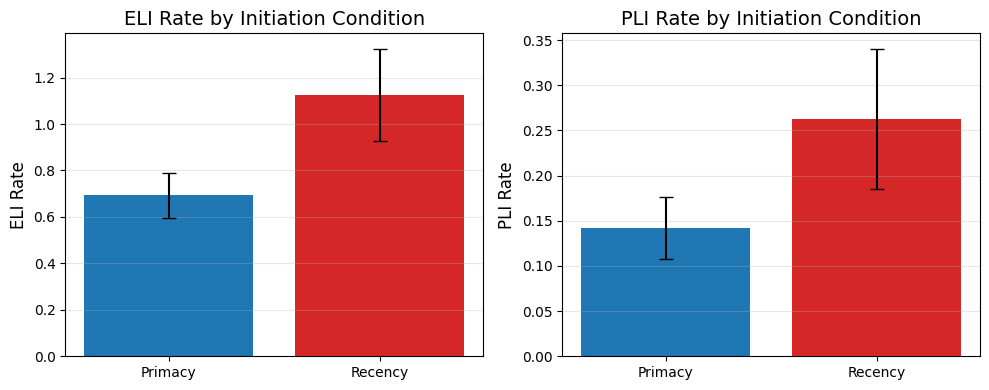

<Figure size 640x480 with 0 Axes>

In [27]:
primacy_eli = intrusion_df[intrusion_df['initiation_condition'] == 'primacy']['eli_rate']
recency_eli = intrusion_df[intrusion_df['initiation_condition'] == 'recency']['eli_rate']

primacy_pli = intrusion_df[intrusion_df['initiation_condition'] == 'primacy']['pli_rate']
recency_pli = intrusion_df[intrusion_df['initiation_condition'] == 'recency']['pli_rate']

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(['Primacy', 'Recency'], [primacy_eli.mean(), recency_eli.mean()], yerr=[primacy_eli.sem(), recency_eli.sem()], color=['#1f77b4', '#d62728'], capsize=5)
ax[0].set_ylabel('ELI Rate', fontsize=12)
ax[0].set_title('ELI Rate by Initiation Condition', fontsize=14)
ax[0].grid(axis='y', alpha=0.3)
ax[1].bar(['Primacy', 'Recency'], [primacy_pli.mean(), recency_pli.mean()], yerr=[primacy_pli.sem(), recency_pli.sem()], color=['#1f77b4', '#d62728'], capsize=5)
ax[1].set_ylabel('PLI Rate', fontsize=12)
ax[1].set_title('PLI Rate by Initiation Condition', fontsize=14)
ax[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('figures/intrusion_rates_by_condition.png', dpi=150)

## 5. Temporal clustering score

In [28]:
tcl_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    ll = int(data['l_length'].dropna().iloc[0])
    cond = data['initiation_condition'].dropna().iloc[0]
    tcl = analyses.tcl_sess(data, ll, buffer=0)
    tcl_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond, 'tcl': tcl
    })
tcl_df = pd.DataFrame(tcl_rows)
tcl_df.head(5)

,prolific_pid,session,initiation_condition,tcl
0,5a8895f0f1408d0001769b7b,0,primacy,0.529037
1,602fd11faa844cd2d0fd5818,0,recency,0.716954
2,602fd11faa844cd2d0fd5818,1,recency,0.684830
3,602fd11faa844cd2d0fd5818,2,primacy,0.782988
4,602fd11faa844cd2d0fd5818,3,primacy,0.755942


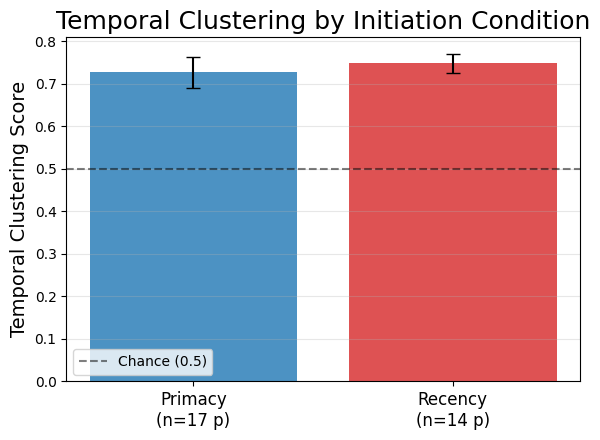

In [29]:
tcl_participant_df = plot_bar_by_condition(
    tcl_df,
    value_col='tcl',
    ylabel='Temporal Clustering Score',
    title='Temporal Clustering by Initiation Condition',
    figure_path='figures/tcl_by_condition.png',
    chance=0.5,
)


## 6. Lag-CRP

Lag-CRP is computed per session, then averaged within participant-condition
before plotting condition curves.


In [30]:
lag_crp_rows = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    ll = int(data['l_length'].dropna().iloc[0])
    cond = data['initiation_condition'].dropna().iloc[0]
    crp = analyses.lag_crp_sess(data, ll, buffer=0)
    lag_crp_rows.append({
        'prolific_pid': pid, 'session': sess,
        'initiation_condition': cond, 'l_length': ll,
        **{f'ln_{lag}': crp[i] for i, lag in enumerate(np.arange(ll - 1, 0, -1))},
        **{f'lp_{lag}': crp[(ll - 1) + i] for i, lag in enumerate(range(1, ll))},
    })
lag_crp_df = pd.DataFrame(lag_crp_rows)
lag_cols = [f'ln_{lag}' for lag in np.arange(ll - 1, 0, -1)] + [f'lp_{lag}' for lag in range(1, ll)]
lags = np.r_[np.arange(-(ll - 1), 0), np.arange(1, ll)]
lag_crp_participant_df, lag_crp_mean, lag_crp_sem, lag_crp_n = condition_summary(lag_crp_df, lag_cols)
lag_crp_df.head(5)

,prolific_pid,session,initiation_condition,l_length,ln_19,ln_18,ln_17,ln_16,ln_15,ln_14,...,lp_10,lp_11,lp_12,lp_13,lp_14,lp_15,lp_16,lp_17,lp_18,lp_19
0,5a8895f0f1408d0001769b7b,0,primacy,20,NaN,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.125,0.142857,0.6
1,602fd11faa844cd2d0fd5818,0,recency,20,0.000000,NaN,0.0,0.0,0.000000,0.000000,...,0.285714,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000,0.000000,NaN
2,602fd11faa844cd2d0fd5818,1,recency,20,0.333333,0.333333,0.0,0.0,0.083333,0.076923,...,0.023810,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000,0.000000,0.0
3,602fd11faa844cd2d0fd5818,2,primacy,20,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.066667,0.0,0.000000,0.0,0.0,0.076923,0.0,0.000,0.000000,0.0
4,602fd11faa844cd2d0fd5818,3,primacy,20,NaN,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.027778,0.0,0.0,0.000000,0.0,0.000,0.000000,0.1


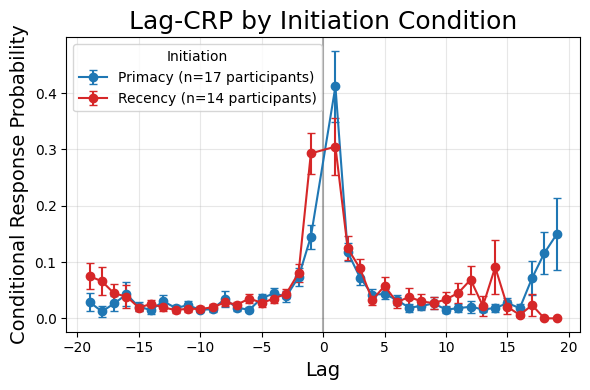

In [31]:
fig, ax = plt.subplots(figsize=(6,4))
for cond in cond_order:
    if cond not in lag_crp_mean.index:
        continue
    vals = lag_crp_mean.loc[cond, lag_cols].values
    errs = lag_crp_sem.loc[cond, lag_cols].fillna(0).values
    ax.errorbar(
        lags, vals, yerr=errs,
        label=f'{cond.capitalize()} (n={int(lag_crp_n.loc[cond])} participants)',
        color=colors.get(cond, 'gray'), marker='o', capsize=3
    )
ax.axvline(0, color='black', alpha=0.3)
ax.set_xlabel('Lag', fontsize=14)
ax.set_ylabel('Conditional Response Probability', fontsize=14)
ax.set_title('Lag-CRP by Initiation Condition', fontsize=18)
ax.legend(title='Initiation')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/lag_crp_by_condition.png', dpi=150)
plt.show()


## 7. Inter-Response Times

In [32]:
irt_dfs = []
for (pid, sess), data in df.groupby(['prolific_pid', 'session']):
    ll = int(data['l_length'].dropna().iloc[0])
    cond = data['initiation_condition'].dropna().iloc[0]
    irt_per_sess = analyses.irt_sess(data, ll)
    irt_per_sess['prolific_pid'] = pid
    irt_per_sess['session'] = sess
    irt_per_sess['initiation_condition'] = cond
    irt_dfs.append(irt_per_sess)
irt_df = pd.concat(irt_dfs, ignore_index=True)
print(f'{len(irt_df)} rows across session/ncr bins')
tr_cols = [c for c in irt_df.columns if c.startswith('tr_')]
irt_participant_df, irt_mean, irt_sem, irt_n = condition_summary(irt_df, tr_cols)
display(irt_mean.round(1))


341 rows across session/ncr bins


,tr_1,tr_2,tr_3,tr_4,tr_5,tr_6,tr_7,tr_8,tr_9,tr_10,tr_11,tr_12,tr_13,tr_14,tr_15,tr_16,tr_17,tr_18,tr_19
initiation_condition,,,,,,,,,,,,,,,,,,,
primacy,2625.3,2723.8,3403.9,3921.4,4666.5,3310.3,3825.3,5906.2,3543.0,3835.1,3493.9,2659.2,3122.5,3558.6,3646.6,2352.0,2219.1,2398.2,2578.3
recency,2825.6,2738.5,3669.0,4182.0,5080.2,4618.4,5303.2,5093.1,7671.2,4707.3,7343.1,8032.2,3700.6,3162.0,4911.7,2087.2,1820.5,2135.8,NaN


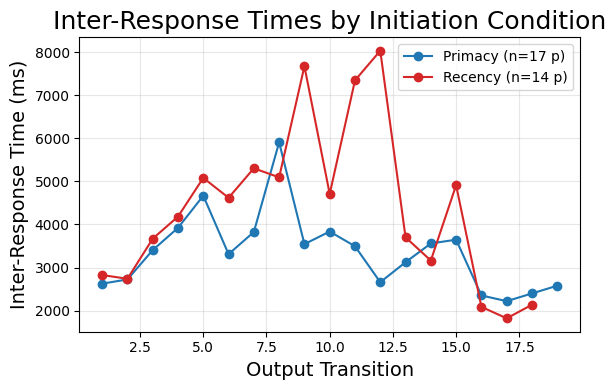

In [33]:
fig, ax = plt.subplots(figsize=(6,4))
tr_cols = [c for c in irt_df.columns if c.startswith('tr_')]
irt_participant_df, irt_by_cond, irt_sem, irt_n = condition_summary(irt_df, tr_cols)
for cond in cond_order:
    if cond in irt_by_cond.index:
        vals = irt_by_cond.loc[cond].values
        transitions = np.arange(1, len(vals) + 1)
        valid = ~np.isnan(vals)
        ax.plot(
            transitions[valid], vals[valid],
            label=f'{cond.capitalize()} (n={int(irt_n.loc[cond])} p)',
            color=colors[cond], marker='o'
        )
ax.set_xlabel('Output Transition', fontsize=14)
ax.set_ylabel('Inter-Response Time (ms)', fontsize=14)
ax.set_title('Inter-Response Times by Initiation Condition', fontsize=18)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/irt_by_condition.png', dpi=150)
plt.show()

## 8. Paper-Style Figures

These figures reuse the Prolific analysis tables above, but apply plotting conventions from `figures/figures.py` so they visually resemble the original paper figures.

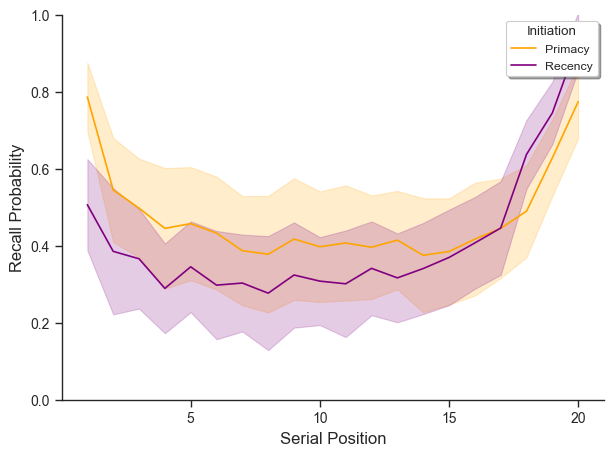

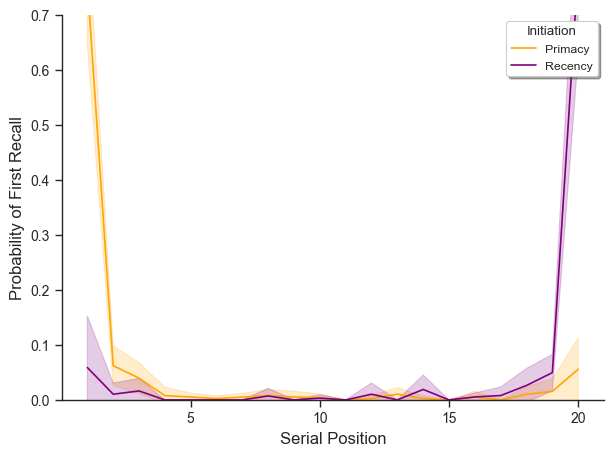

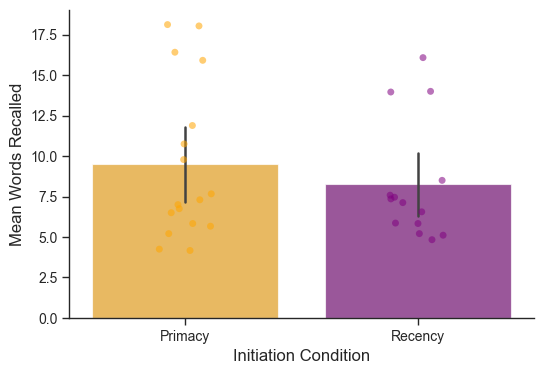

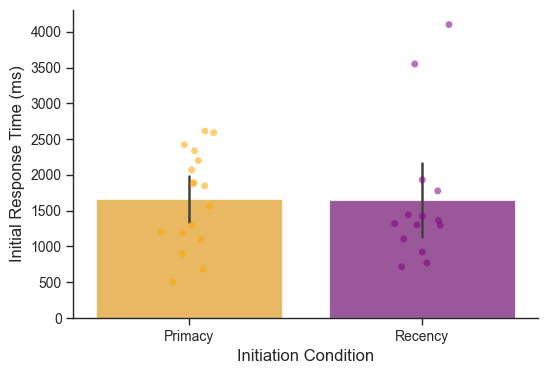

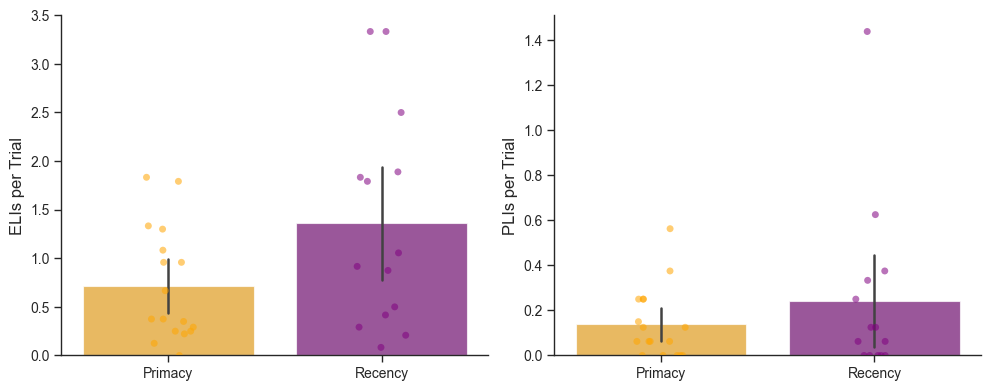

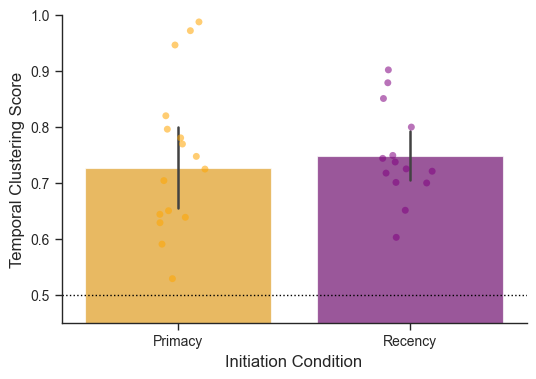

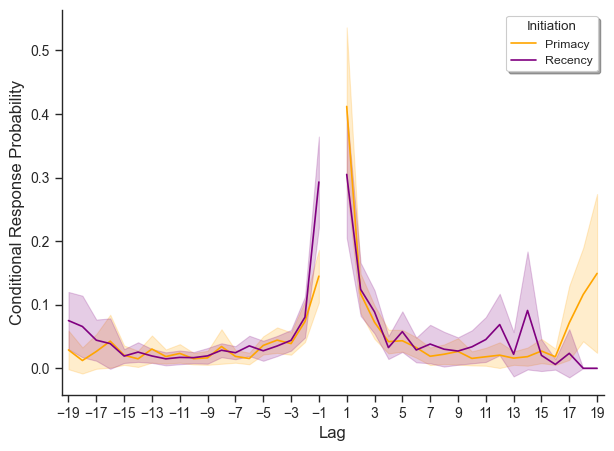

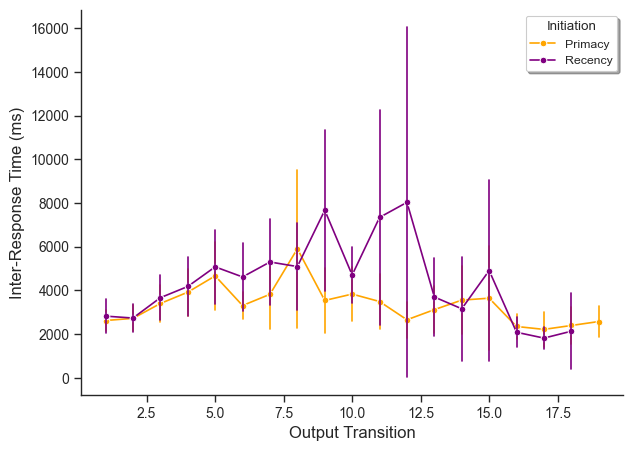

In [35]:
import figures.prolific_paper_figures as ppf

paper_fig_dir = 'figures/prolific_paper_style'

ppf.plot_curve_by_condition(
    spc_df,
    sp_cols,
    ylabel='Recall Probability',
    path=f'{paper_fig_dir}/spc_by_condition.pdf',
    ylim=(0, 1),
)

ppf.plot_curve_by_condition(
    pfr_df,
    sp_cols,
    ylabel='Probability of First Recall',
    path=f'{paper_fig_dir}/pfr_by_condition.pdf',
    ylim=(0, 0.7),
)

ppf.plot_bar_by_condition(
    mwr_df,
    value_col='mwr',
    ylabel='Mean Words Recalled',
    path=f'{paper_fig_dir}/mwr_by_condition.pdf',
)

ppf.plot_bar_by_condition(
    rt_init_df,
    value_col='rt_init',
    ylabel='Initial Response Time (ms)',
    path=f'{paper_fig_dir}/rt_init_by_condition.pdf',
)

ppf.plot_intrusion_rates(
    intrusion_df,
    path=f'{paper_fig_dir}/intrusion_rates_by_condition.pdf',
)

ppf.plot_bar_by_condition(
    tcl_df,
    value_col='tcl',
    ylabel='Temporal Clustering Score',
    path=f'{paper_fig_dir}/tcl_by_condition.pdf',
    ylim=(0.45, 1),
    chance=0.5,
)

ppf.plot_lag_crp(
    lag_crp_df,
    lag_cols,
    path=f'{paper_fig_dir}/lag_crp_by_condition.pdf',
)

ppf.plot_irt(
    irt_df,
    tr_cols,
    path=f'{paper_fig_dir}/irt_by_condition.pdf',
)
